In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path = "/content/drive/MyDrive/Mecine Learning/Praktikum10"

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

In [6]:
df = pd.read_excel ('/content/drive/MyDrive/Mecine Learning/Praktikum10/data/data temperatur.xlsx')
df

,Temperatur Udara (°C),Kecepatan Angin (km/jam),Klasifikasi
0,10,0,Dingin
1,25,0,Panas
2,15,5,Dingin
3,20,3,Panas
4,18,7,Dingin
5,20,10,Dingin
6,22,5,Panas
7,24,6,Panas


In [8]:
# Data uji
x_test = np.array([16, 3])

# Hitung jarak Euclidean
df["Jarak"] = np.sqrt((df["Temperatur Udara (°C)"] - x_test[0])**2 + (df["Kecepatan Angin (km/jam)"] - x_test[1])**2)

# Urutkan berdasarkan jarak
df_sorted = df.sort_values("Jarak")
df_sorted

,Temperatur Udara (°C),Kecepatan Angin (km/jam),Klasifikasi,Jarak
2,15,5,Dingin,2.236068
3,20,3,Panas,4.000000
4,18,7,Dingin,4.472136
6,22,5,Panas,6.324555
0,10,0,Dingin,6.708204
5,20,10,Dingin,8.062258
7,24,6,Panas,8.544004
1,25,0,Panas,9.486833


In [9]:
K = 3

neighbors = df_sorted.head(K)
neighbors

,Temperatur Udara (°C),Kecepatan Angin (km/jam),Klasifikasi,Jarak
2,15,5,Dingin,2.236068
3,20,3,Panas,4.000000
4,18,7,Dingin,4.472136


In [11]:
hasil_manual = neighbors["Klasifikasi"].value_counts().idxmax()
hasil_manual

'Dingin'

In [13]:
X = df[["Temperatur Udara (°C)", "Kecepatan Angin (km/jam)"]]
y = df["Klasifikasi"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

model.predict([[16, 3]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array(['Dingin'], dtype=object)

In [14]:
accuracies = {}
for k in [1, 3, 5]:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=4)
    accuracies[k] = scores.mean()

accuracies

{1: np.float64(1.0), 3: np.float64(0.875), 5: np.float64(0.75)}

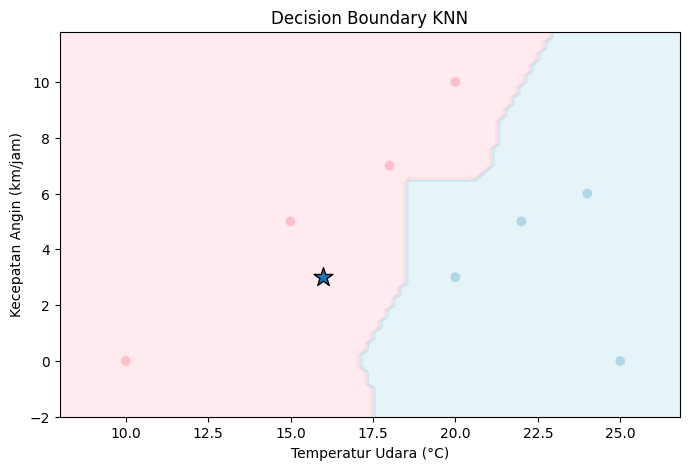

In [20]:
X_plot = df[["Temperatur Udara (°C)", "Kecepatan Angin (km/jam)"]].values
y_plot = np.where(df["Klasifikasi"] == "Panas", 1, 0)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_plot, y_plot)

x_min, x_max = X_plot[:,0].min()-2, X_plot[:,0].max()+2
y_min, y_max = X_plot[:,1].min()-2, X_plot[:,1].max()+2
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.2),
                     np.arange(y_min, y_max, 0.2))

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#FFC0CB', '#ADD8E6']) # Example colors for two classes

plt.figure(figsize=(8,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=custom_cmap)

plt.scatter(df["Temperatur Udara (°C)"], df["Kecepatan Angin (km/jam)"], c=y_plot, cmap=custom_cmap)
plt.scatter(16, 3, marker='*', s=200, edgecolors='black')

plt.xlabel("Temperatur Udara (°C)")
plt.ylabel("Kecepatan Angin (km/jam)")
plt.title("Decision Boundary KNN")
plt.show()